# Transverse contraction

The goal of this section is to introduce a new algorithm to represent to represent correctly the expected value of an operator after some time evolution.

The idea is the following, we write the full tensor network required (a). Then, we realize that we have a forward and a backward branch of the evolution and fold the network (b). Finally, we see that there is an effective light-cone given by the starting brickwall circuit due to cancellation of $U(dt)$ and $U(dt)^\dagger$. This light-cone could be further enforced using the velocity (Lieb-Robinson bounds), but it is safer to just follow the naive light-cone (c).

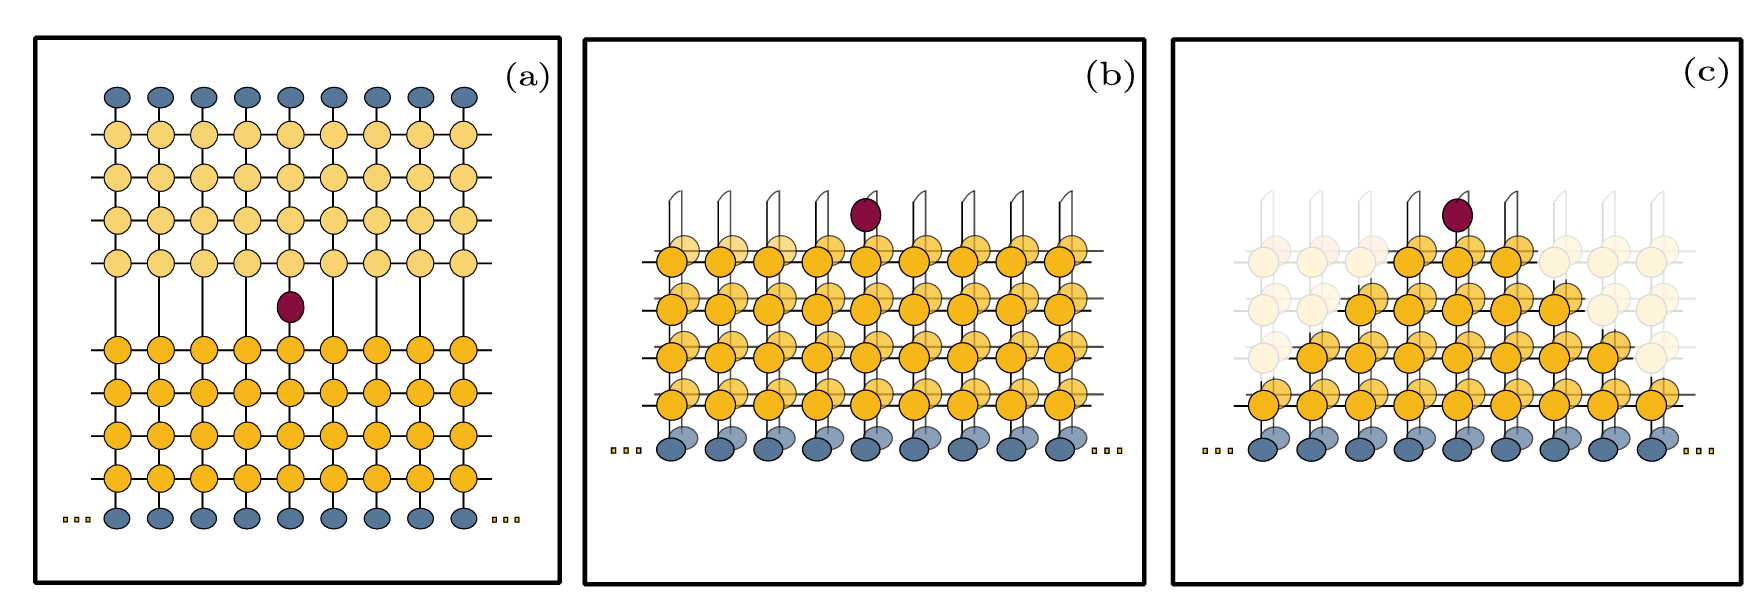
Picture from (doi:10.21468/SciPostPhysCodeb.63) where `ITransverse.jl` is introduced.

The network can be contrcted as usual, following the time direction. Or in the tranverse direction i.e. from left to right. This is what we will be doing in this tutorial.

The idea is fairly simple, you can decompose your gates as you would do it in TEBD but now, instead of applying them from the initial state up to a time $t$, you apply the gates transversely.
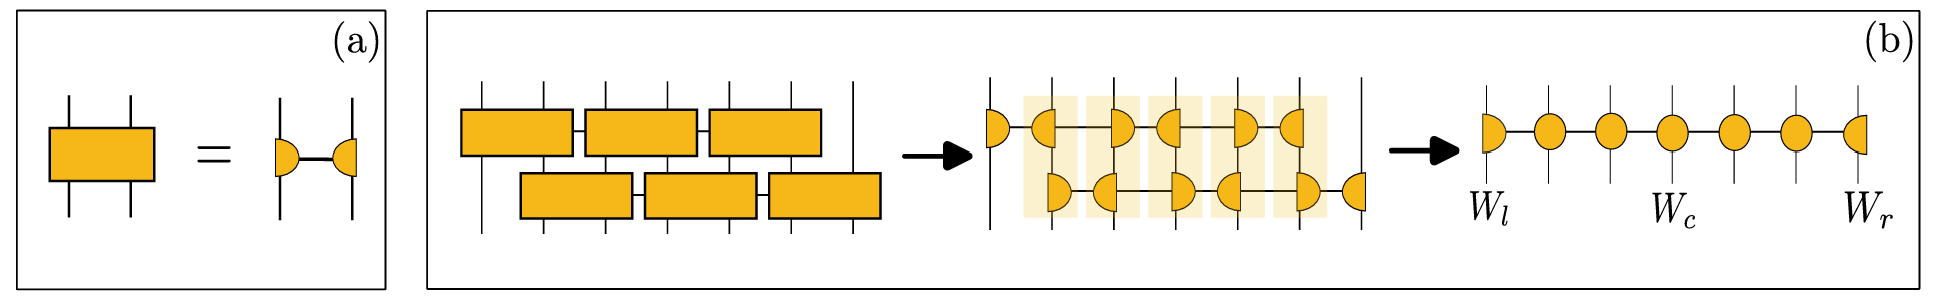

## ITransverse.jl makes your life easier

In this case, we are just showcasing another way to obtain the expected value $<Z>$ for the evolution given by iTEBD. We are in the same scenario and using ITransverse.jl and the transverse contraction we can compute the same quantities as before (more information in doi:10.21468/SciPostPhysCodeb.63 and doi:10.1103/PhysRevResearch.6.033021).

Below, there is the code to run a simulation using the light-cone agorithm. It returns the left and right eigenvectors with the lowest eigenvalue of the transverse matrix defined as the vertical column of the time evolution network. It also saves to your computer a file called `"OUTcone_final.jld2"` which has the information about the expected value, the temporal entropy and the generalized temporal entropy.


### Playaround 

Run it for the same case as for the iTEBD and compare results. The $dt$ can be left as it is.

In [94]:
using ITensors, ITensorMPS
using JLD2
using Plots

using ITransverse

function main_cone()

    JXX = 1.0  
    hz = 0.4
    gx = 0.0 # 0.5

    dt = 0.05

    nbeta = 0

    optimize_op = vX
    init_state = up_state

    cutoff = 1e-10
    maxdim = 128
    direction = :left
    alg = "densitymatrix"

    truncp = (;cutoff, maxdim, direction, alg)

    numiter = 100

    #time_sites = siteinds("S=3/2", 1)

    mp = IsingParams(JXX, hz, gx)
    tp = tMPOParams(mp; dt, scheme=SymSVD(), nbeta, init_state)
    b = FoldtMPOBlocks(tp)
    c0 = init_cone(b)

    #@info length(c0)

    cone_params = ConeParams(;truncp, opt_method=:sym, optimize_op)

    cp = DoCheckpoint(
        "cp_cone_$(JXX)_$(hz)_$(gx)_xx.jld2";
        params=Dict("tparams" => tp, "cparams" => cone_params),
        save_at = [],
        f_obs = (
            SVN = s -> vn_entanglement_entropy(s.R),
            S_SVD = s -> generalized_svd_vn_entropy(s.L, s.R),
            overlap = s -> overlap_noconj(s.L, s.R),
            expvals = s -> ITransverse.compute_expvals(s.L, s.R, ["Z"], s.b),
            chis = s -> maxlinkdim(s.R)
        ),
        f_savestate = (
            L = s -> s.L,
            R = s -> s.R,
            b = s -> s.b
        )
    )

    psi, psiR, checkpt = run_cone(c0, b, cone_params, cp, numiter)

    return  psi, psiR, checkpt

end

main_cone (generic function with 1 method)

In [95]:
main_cone()

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter C:\Users\abouc\.julia\packages\ProgressMeter\N660J\src\ProgressMeter.jl:607
[cone(v=1)|sym|densitymatrix] [ψ0=>Op] cutoff=1.0e-10, maxdim=128) 100% Time: 0:02:06 ( 1.34  s/it)
   Info: [100] χ=43, (L|R) = 0.9999999094503454 - 8.486622747719044e-15im 
[ Info: Saving CP OUTcone_final.jld2...


(MPS
[1] ((dim=4|id=613|"Site,n=1,time_fold"), (dim=4|id=712|"CMB,Link,l=1"))
[2] ((dim=4|id=842|"Site,n=2,time_fold"), (dim=4|id=712|"CMB,Link,l=1"), (dim=11|id=908|"CMB,Link,l=2"))
[3] ((dim=4|id=5|"Site,n=3,time_fold"), (dim=11|id=908|"CMB,Link,l=2"), (dim=12|id=842|"CMB,Link,l=3"))
[4] ((dim=4|id=287|"Site,n=4,time_fold"), (dim=12|id=842|"CMB,Link,l=3"), (dim=12|id=929|"CMB,Link,l=4"))
[5] ((dim=4|id=31|"Site,n=5,time_fold"), (dim=12|id=929|"CMB,Link,l=4"), (dim=12|id=776|"CMB,Link,l=5"))
[6] ((dim=4|id=269|"Site,n=6,time_fold"), (dim=12|id=776|"CMB,Link,l=5"), (dim=15|id=818|"Link,l=6,time_fold"))
[7] ((dim=4|id=240|"Site,n=7,time_fold"), (dim=15|id=818|"Link,l=6,time_fold"), (dim=17|id=625|"Link,l=7,time_fold"))
[8] ((dim=4|id=598|"Site,n=8,time_fold"), (dim=17|id=625|"Link,l=7,time_fold"), (dim=19|id=918|"Link,l=8,time_fold"))
[9] ((dim=4|id=57|"Site,n=9,time_fold"), (dim=19|id=918|"Link,l=8,time_fold"), (dim=20|id=107|"Link,l=9,time_fold"))
[10] ((dim=4|id=942|"Site,n=10,time_f

_NOTE_: Make sure that the PATH is the correct one.

_NOTE 2_: If you rerun the simulation remove or change the name of the previous file. Sometimes, the file is not overwritten and your new information will not be updated.

_NOTE 3_: If you change the information of $dt$ or `numiter` make sure you also change it below if not the plots will not coincide with what you expect.

In [99]:
numiter=100
dt =0.05

PATH = "OUTcone_final.jld2"
aa = load(PATH)["observables"]
sZ = []

ent_si = aa[:SVN]
entropy = []
for i=1:length(ent_si)
    push!(sZ , real(aa[:expvals][i]["Z"]))
    push!(entropy, -sum(ent_si[i].^2 .*log.(ent_si[i].^2)))
end

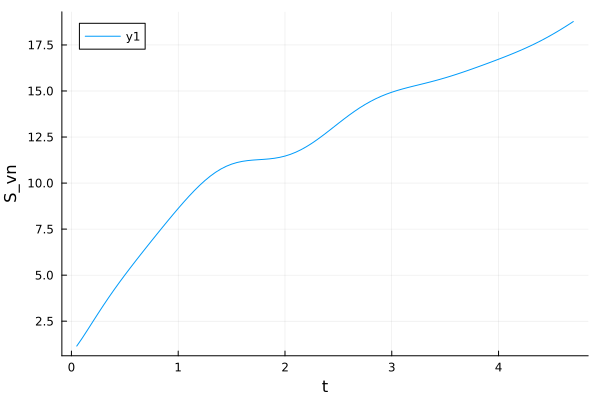

In [100]:
plot((dt:dt:dt*length(entropy)),entropy)
xlabel!("t")
ylabel!("S_vn")

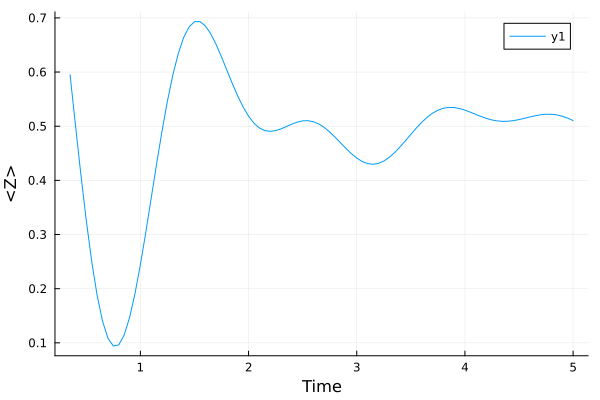

In [101]:

plot(((numiter-length(sZ)+1)*dt:dt:dt*numiter), sZ)
#xlims!(0,5)
xlabel!("Time")
ylabel!("<Z>")